# Quantum Channel Baseline Comparison

This notebook documents and exercises the end-to-end benchmark path used for the
baseline channel sweep.

For each channel, the notebook:

- draws QPSK symbols from `{0, 1, 2, 3}`,
- prepares matching `2 x 2` density-matrix codewords with `QPSKModulator`,
- applies `channel.apply(rho)` to each transmitted state,
- detects with `PrettyGoodMeasurementDetector` built from the same reference-state codebook,
- computes BER from full two-bit labels and SER from hard symbol decisions.

This matched transmit/receive path is intentional. It makes BER and SER
scientifically interpretable by isolating channel impairment from detector-path
mismatch.

Academic References:
  - Nielsen, M.A. & Chuang, I.L., Quantum Computation and Quantum Information,
    Cambridge University Press, 2010. Ch. 8 (Quantum channels).
  - Bennett, C.H. et al., Capacities of quantum erasure channels,
    Phys. Rev. Lett., 78(16), 3217, 1997.
  - Giovannetti, V. et al., Bosonic Gaussian channels, arXiv:quant-ph/0404050, 2004.
  - Jurado-Navas, A. et al., A unified statistical model for Malaga distributed optical
    scattering communications, Optics Communications, 468, 126204, 2020.
  - Gordon, J.P. & Kogelnik, H., PMD fundamentals: polarization mode dispersion in optical fibers,
    PNAS, 97(9), 4541-4550, 2000.


## Interpreting the channel effects

For each channel below we run the same matched QPSK transmit/receive chain and
plot pre- and post-channel constellations using the leading qubit block of each
density matrix.

- **Depolarizing channel**: applies `E(rho) = (1 - p) rho + p I / 2`, so Bloch
  vectors contract isotropically toward the origin.
- **Dephasing channel**: implements true phase damping. Populations stay fixed
  while off-diagonal coherence terms shrink by a factor of `1 - p`.
- **Erasure channel**: with probability `p` the output is moved to an orthogonal
  flag state and the detector can return symbol label `-1`. In the projected
  qubit block, the surviving constellation is attenuated because some probability
  mass has left the original code space.
- **Bosonic loss channel**: mixes the signal mode with a thermal environment on a
  beamsplitter in a truncated Fock basis. In this notebook we often use `dim = 2`,
  so the model acts on the vacuum / one-photon subspace rather than a full
  continuous-variable field representation.
- **Turbulence channel**: samples random transmissivity from a Gamma-Gamma or
  Malaga-inspired fading surrogate and then applies bosonic pure loss. It models
  intensity fading, not full phase-screen wavefront distortion.
- **PMD channel**: uses random principal-state-basis rotations with
  bandwidth-dependent coherence loss. It is a spectrum-averaged polarization-qubit
  surrogate, not a full frequency-dependent Jones-matrix propagator.

This notebook is therefore best read as an interpretable end-to-end benchmark,
not as a complete field-propagation solver.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from quantum_comm_sim.channels.depolarizing_channel import DepolarizingChannel
from quantum_comm_sim.channels.dephasing_channel import DephasingChannel
from quantum_comm_sim.channels.erasure_channel import ErasureChannel
from quantum_comm_sim.channels.bosonic_channel import BosonicChannel
from quantum_comm_sim.channels.turbulence_channel import TurbulenceChannel
from quantum_comm_sim.channels.pmd_channel import PMDChannel

from quantum_comm_sim.metrics.ber_ser import compute_ber, compute_ser
from quantum_comm_sim.transceiver.modulators import QAMModulator, QPSKModulator
from quantum_comm_sim.transceiver.transmitter import Transmitter
from quantum_comm_sim.transceiver.receiver import Receiver
from quantum_comm_sim.transceiver.detectors import PrettyGoodMeasurementDetector
from quantum_comm_sim.utils.visualization import plot_bloch_spheres, plot_constellation

# Results directories (match other experiments)
ROOT = os.path.dirname(os.path.dirname(__file__)) if '__file__' in globals() else os.path.join(os.getcwd(), '..')
RESULTS_ROOT = os.path.join(ROOT, 'results')
DATA_DIR = os.path.join(RESULTS_ROOT, 'data')
FIG_DIR = os.path.join(RESULTS_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
# Modulation control block
MODULATION = 'qam'   # 'qpsk' or 'qam'
M_ORDER = 16          # Used only when MODULATION='qam'
NUM_SYMBOLS = 4000
RNG_SEED = 123

modulation = MODULATION.lower()
if modulation not in {'qpsk', 'qam'}:
    raise ValueError("MODULATION must be either 'qpsk' or 'qam'")
if modulation == 'qam' and M_ORDER < 4:
    raise ValueError('For QAM, M_ORDER must be >= 4')

run_tag = f"{modulation}{'' if modulation == 'qpsk' else f'_{M_ORDER}'}"
print(f"Using modulation={modulation}, M_ORDER={M_ORDER}, NUM_SYMBOLS={NUM_SYMBOLS}, seed={RNG_SEED}")

Using modulation=qam, M_ORDER=16, NUM_SYMBOLS=4000, seed=123


In [3]:
def build_chain(dim=2, modulation='qpsk', m_order=4):
    if modulation.lower() == 'qam':
        mod = QAMModulator(m_order=m_order, dim=dim)
    else:
        mod = QPSKModulator(dim=dim)
    det = PrettyGoodMeasurementDetector(
        mod.reference_states(),
        labels=mod.symbol_alphabet(),
    )
    tx = Transmitter(modulator=mod)
    rx = Receiver(detector=det)
    return tx, rx


# Channel configurations for baseline and tutorial
def get_channel_configs():
    """Return tutorial channel configurations.


    Uses signatures consistent with the implemented channel models.
    QuaternionPMDChannel is excluded here because it does not implement
    the BaseChannel.apply API used by the transmitter/receiver baseline sweep.
    """
    return {
        "depolarizing_p01": lambda: DepolarizingChannel(p=0.1),
        "depolarizing_p05": lambda: DepolarizingChannel(p=0.5),
        "dephasing_p05": lambda: DephasingChannel(p=0.5),
        "erasure_p05": lambda: ErasureChannel(p=0.5),
        "bosonic_loss3db": lambda: BosonicChannel(dim=2, loss_db=3.0, noise_factor=0.05),
        "bosonic_loss6db": lambda: BosonicChannel(dim=2, loss_db=6.0, noise_factor=0.10),
        "turbulence_weak": lambda: TurbulenceChannel(turbulence_model='malaga', alpha=2.5, beta=2.0),
        "turbulence_strong": lambda: TurbulenceChannel(turbulence_model='malaga', alpha=1.2, beta=1.1),
        "pmd_static": lambda: PMDChannel(dgd_mean_ps=10.0, num_sections=10),
    }

In [4]:
def _qam_points_from_states(states, clip=4.0, eps=1.0e-9):
    """Recover approximate complex QAM points from qubit density matrices.

    For QAMModulator we embed points as psi ~ [1, alpha]. For a pure state,
    alpha = rho[1, 0] / rho[0, 0]. We use the same ratio as a robust proxy
    for mildly mixed channel outputs and clip extremes for plotting stability.
    """
    rho = np.asarray(states, dtype=complex)
    if rho.ndim == 2:
        rho = rho[None, ...]
    denom = np.clip(np.real(rho[:, 0, 0]), eps, None)
    alpha = rho[:, 1, 0] / denom
    alpha = np.clip(alpha.real, -clip, clip) + 1j * np.clip(alpha.imag, -clip, clip)
    return alpha


def run_simulation(channel, num_symbols=4000, seed=42, modulation='qpsk', m_order=4):
    np.random.seed(seed)
    tx, rx = build_chain(dim=2, modulation=modulation, m_order=m_order)

    alphabet = tx.modulator.symbol_alphabet()
    tx_symbols = np.random.choice(alphabet, size=num_symbols)
    tx_states = tx.transmit(tx_symbols)
    rx_states = np.array([channel.apply(state) for state in tx_states])
    rx_symbols = rx.receive(rx_states)

    tx_bits = tx.modulator.symbols_to_bits(tx_symbols).reshape(-1)
    rx_bits = tx.modulator.symbols_to_bits(rx_symbols).reshape(-1)
    ber = compute_ber(tx_bits, rx_bits)
    ser = compute_ser(tx_symbols, rx_symbols)

    if modulation.lower() == 'qam':
        tx_points = np.array([tx.modulator.constellation[int(s)] for s in tx_symbols], dtype=complex)
        rx_points = _qam_points_from_states(rx_states)
    else:
        tx_points = tx_states
        rx_points = rx_states

    return ber, ser, tx_states, rx_states, tx_symbols, tx_points, rx_points

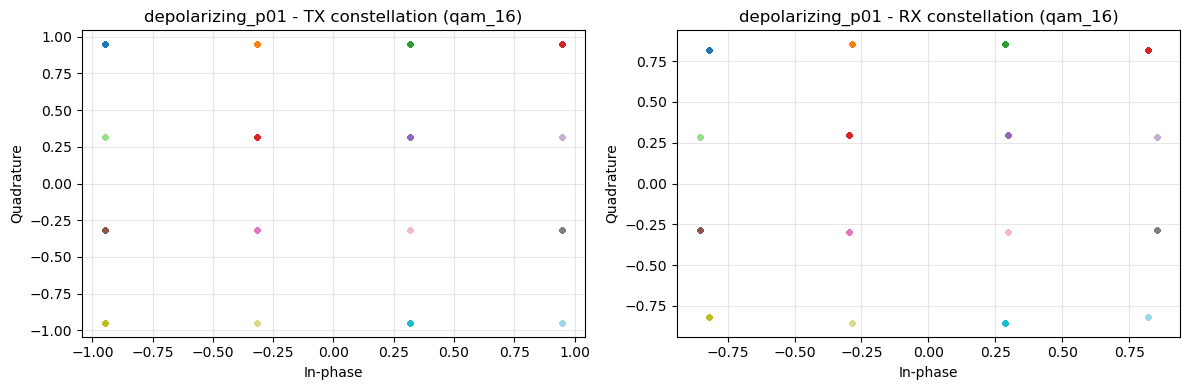

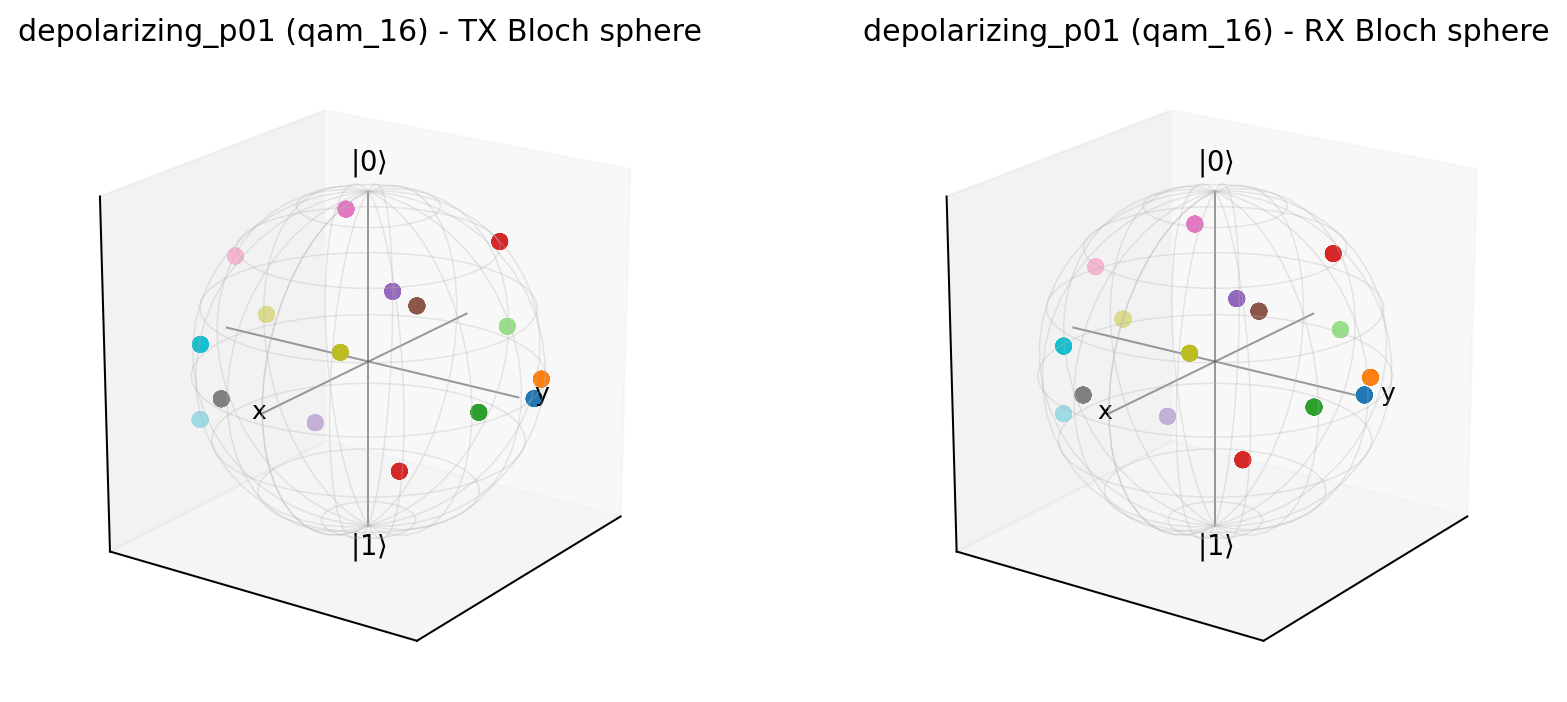

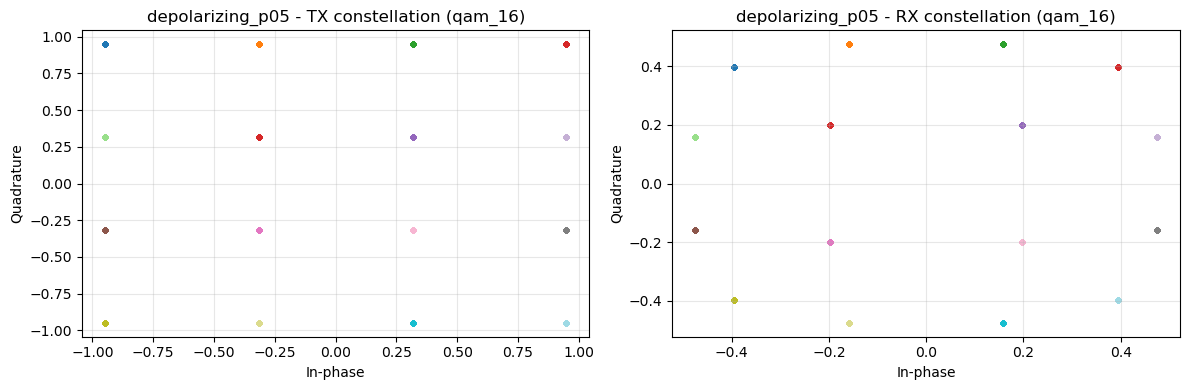

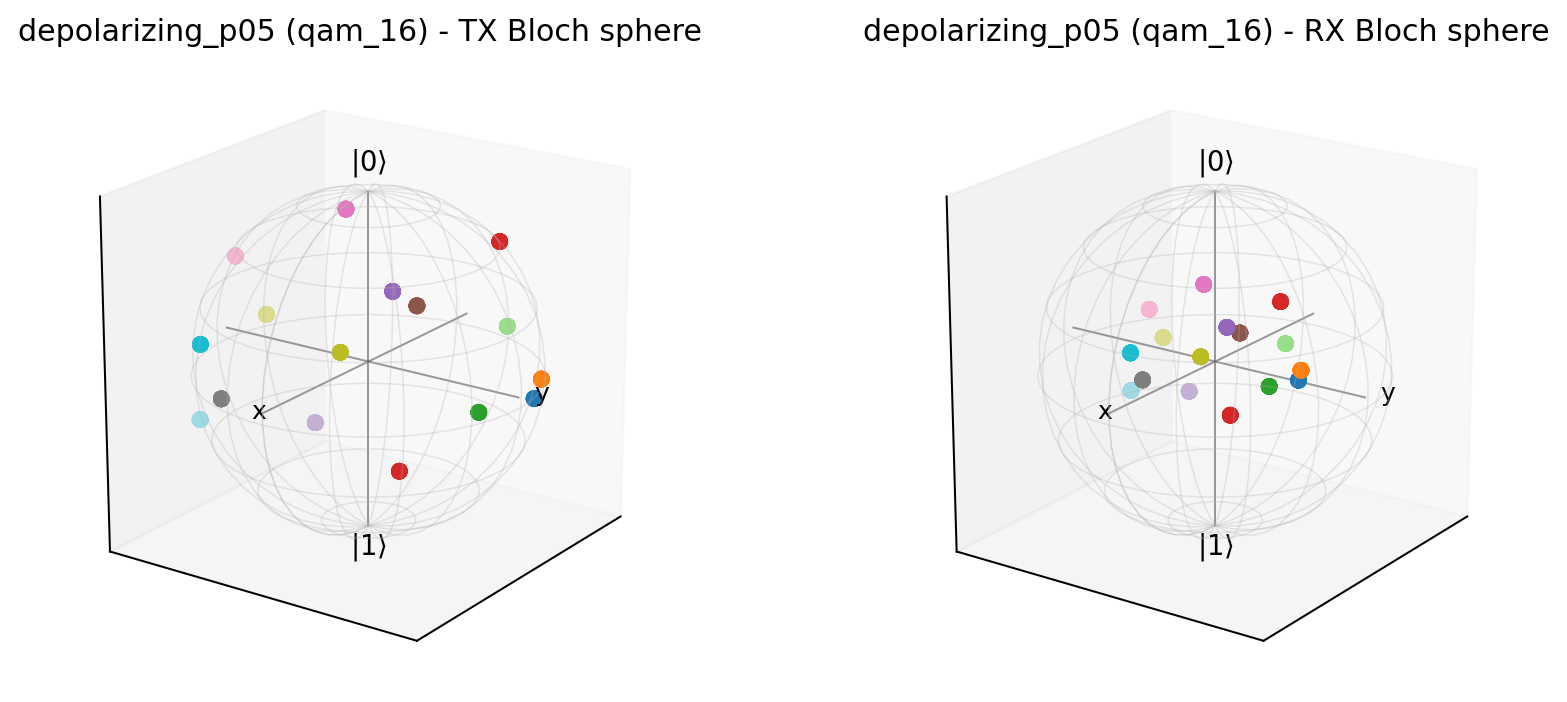

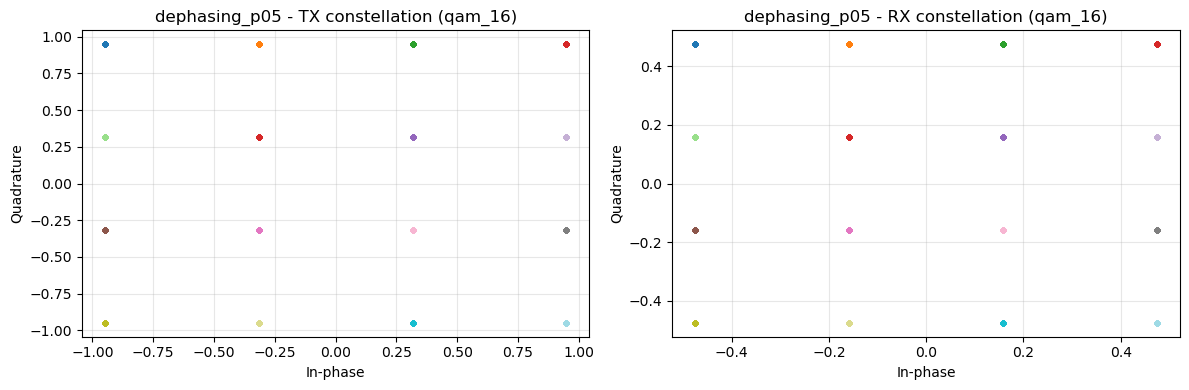

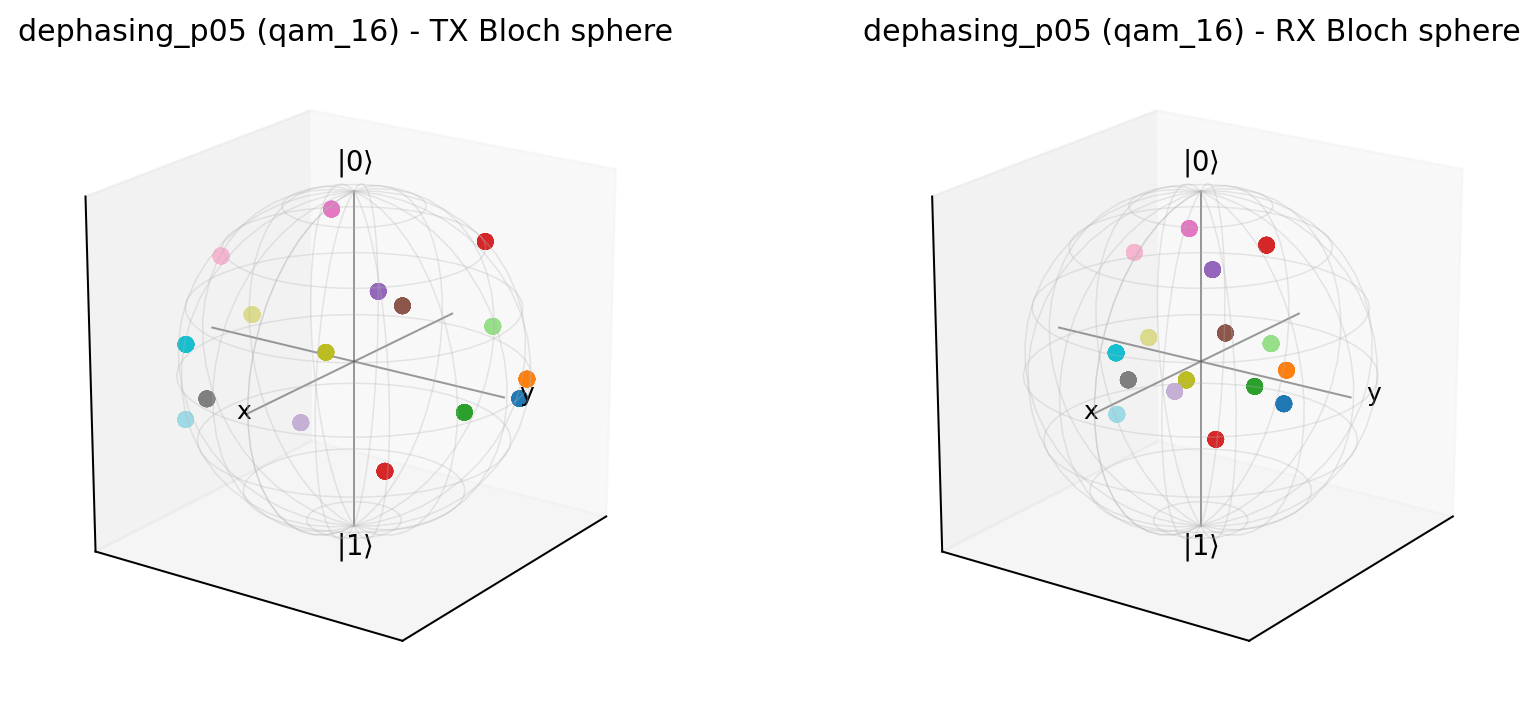

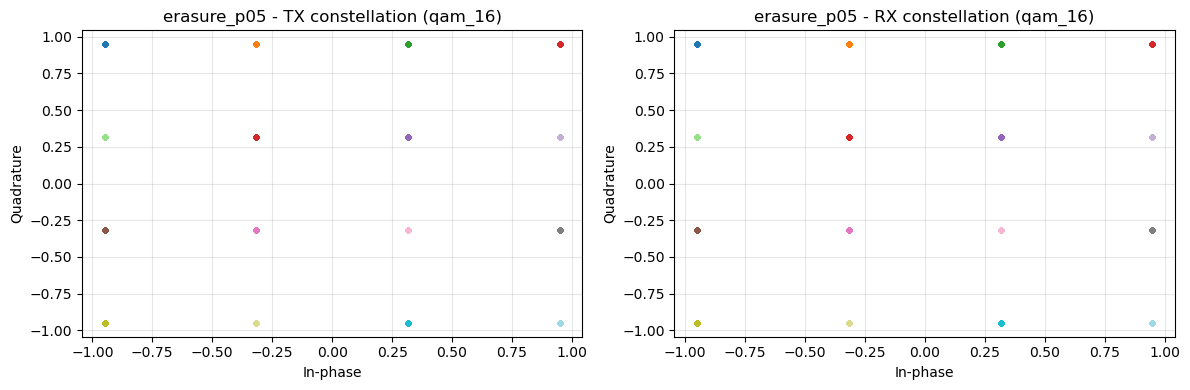

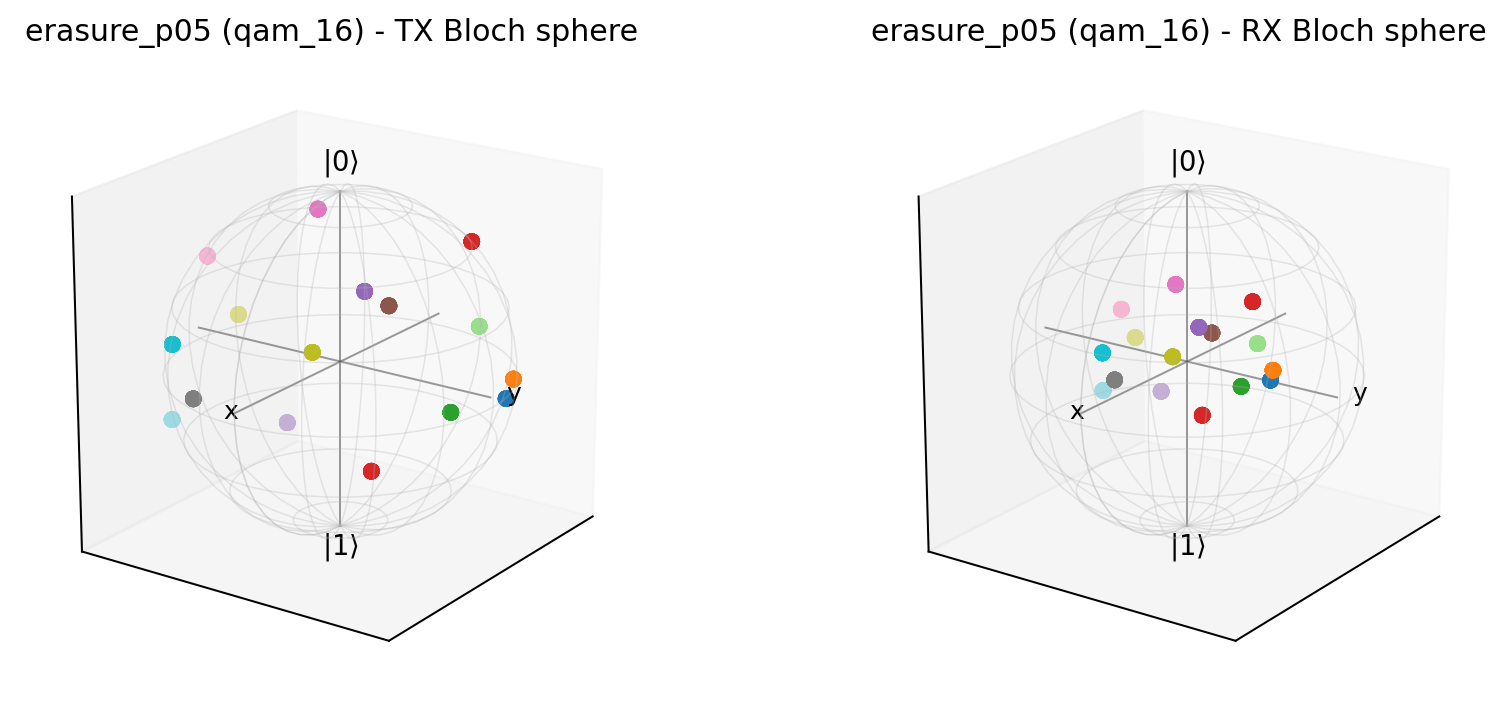

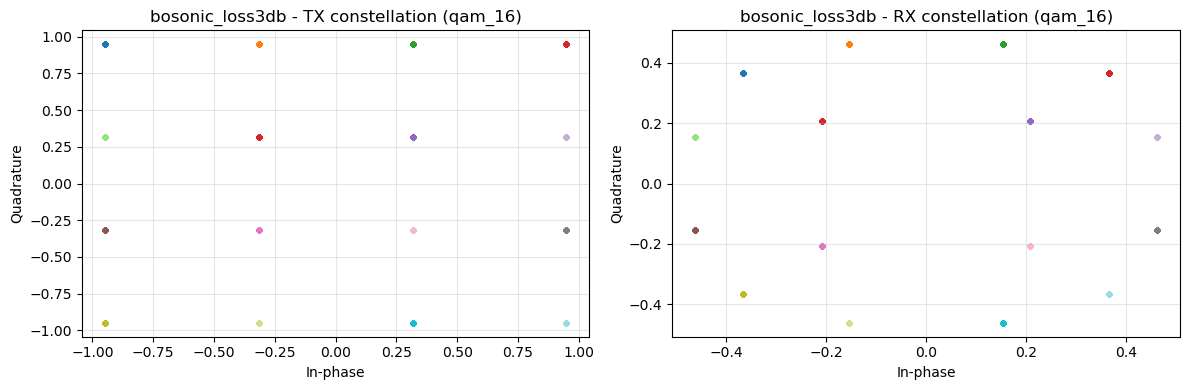

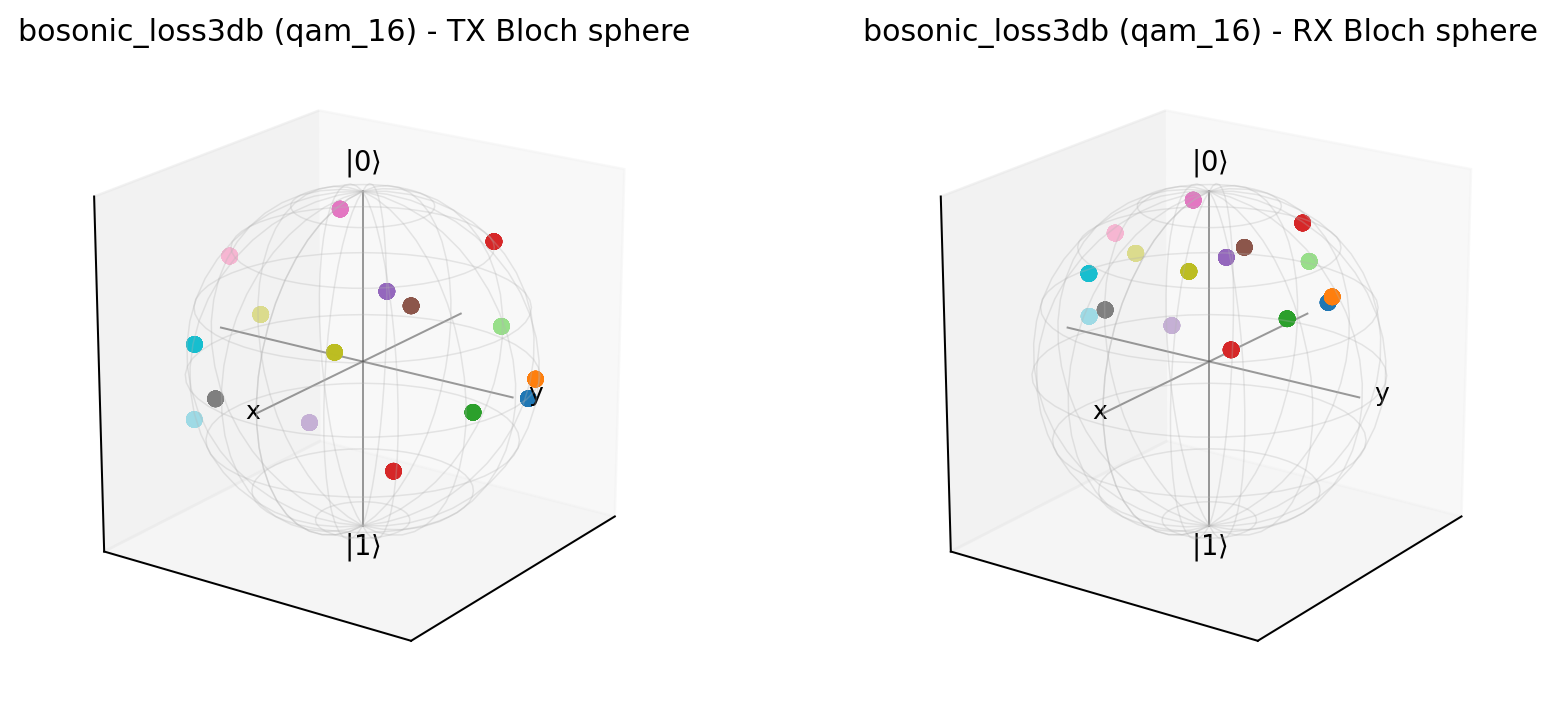

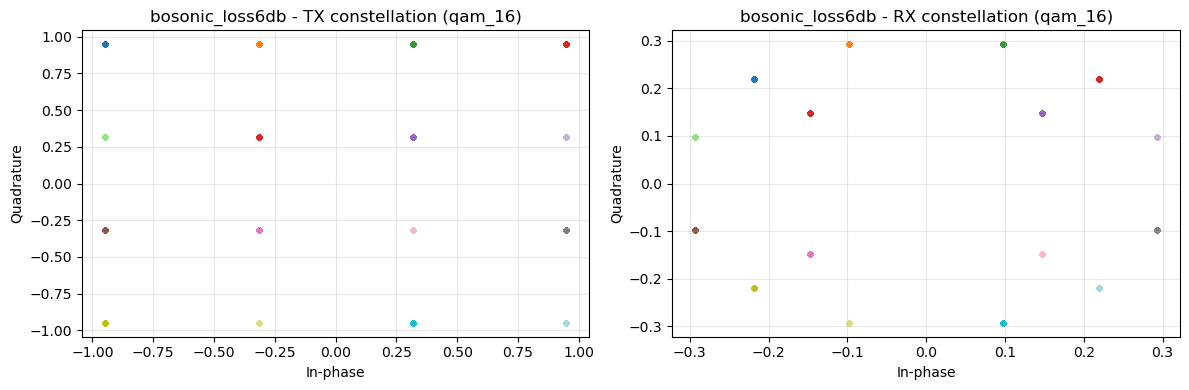

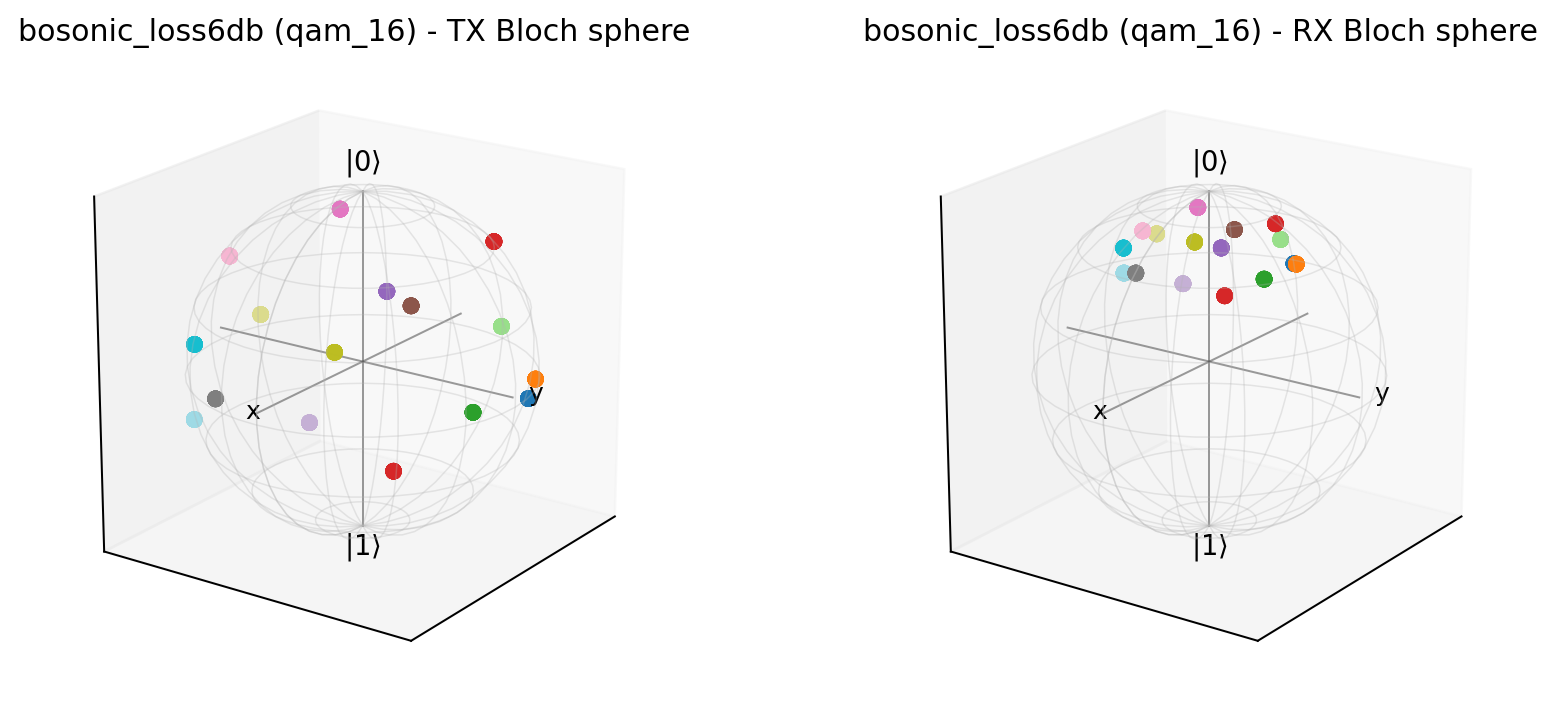

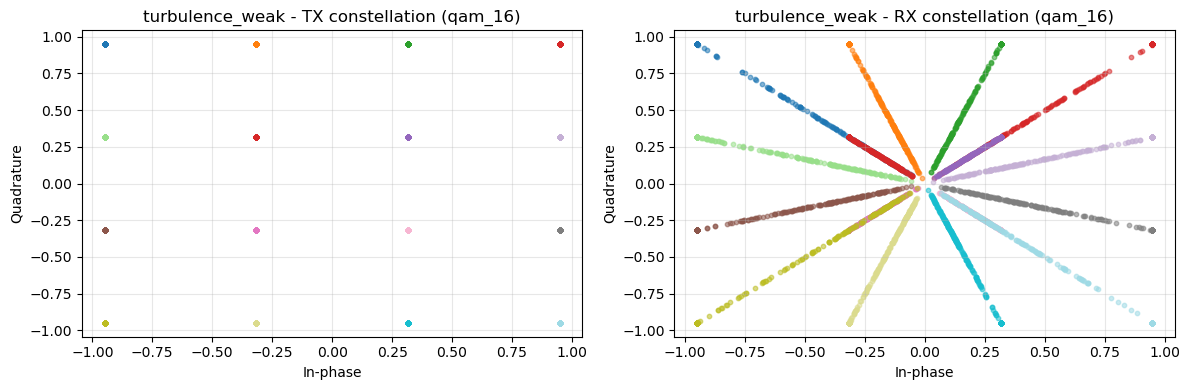

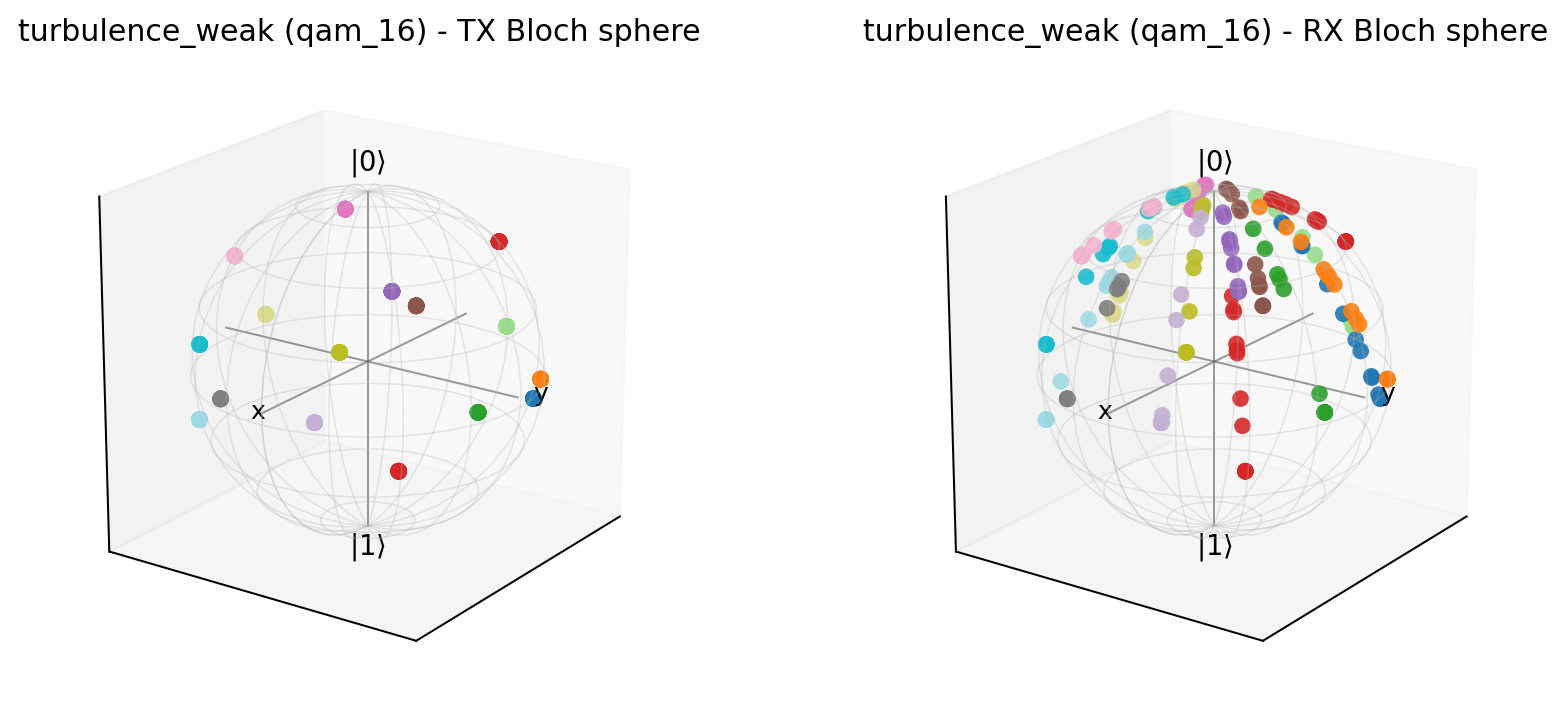

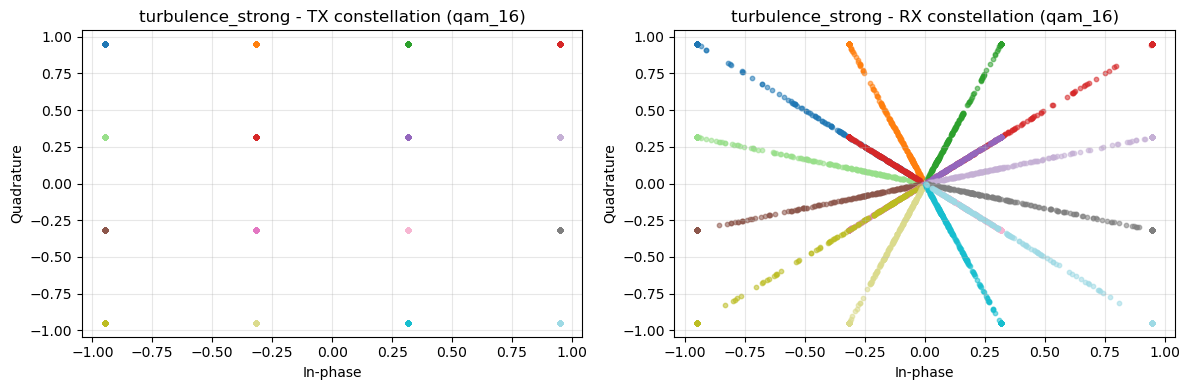

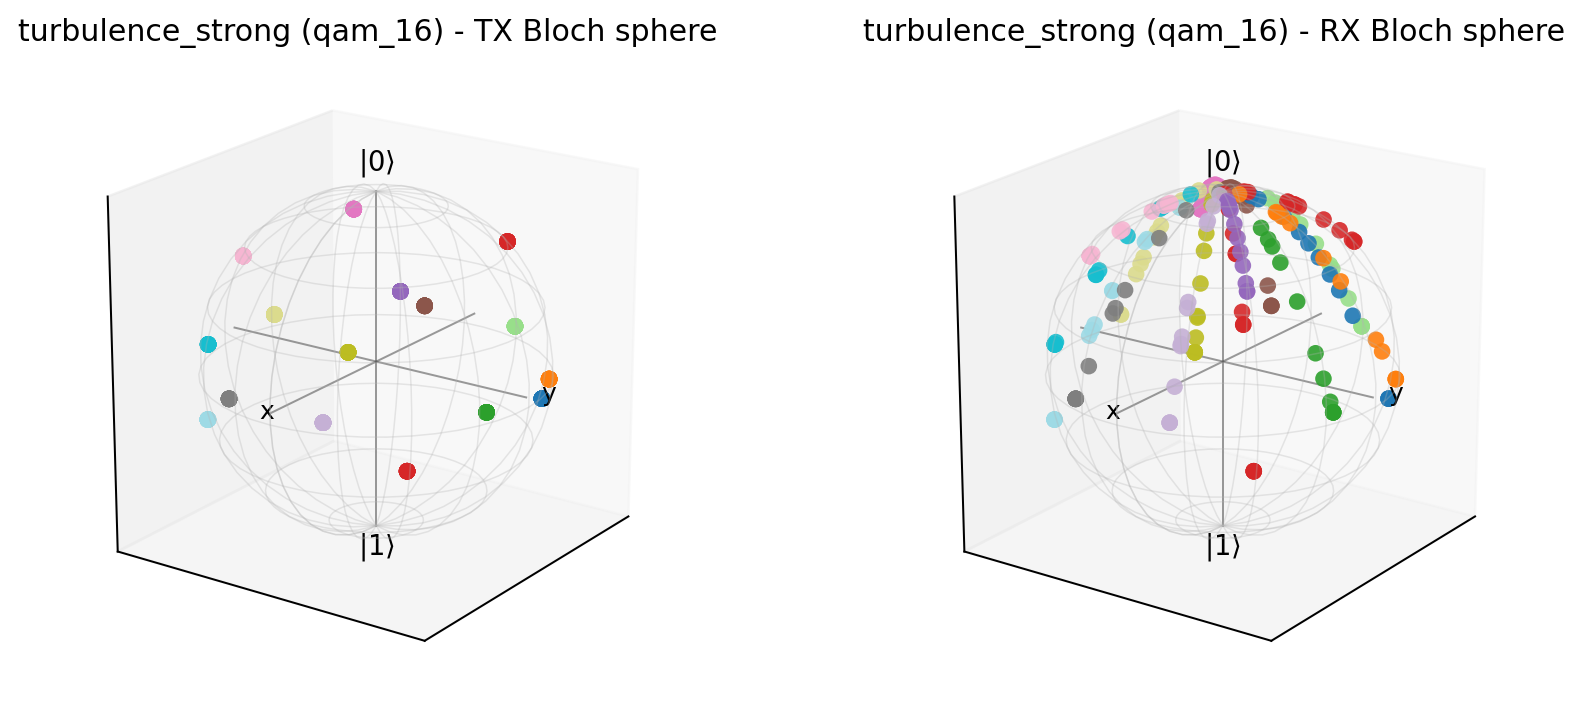

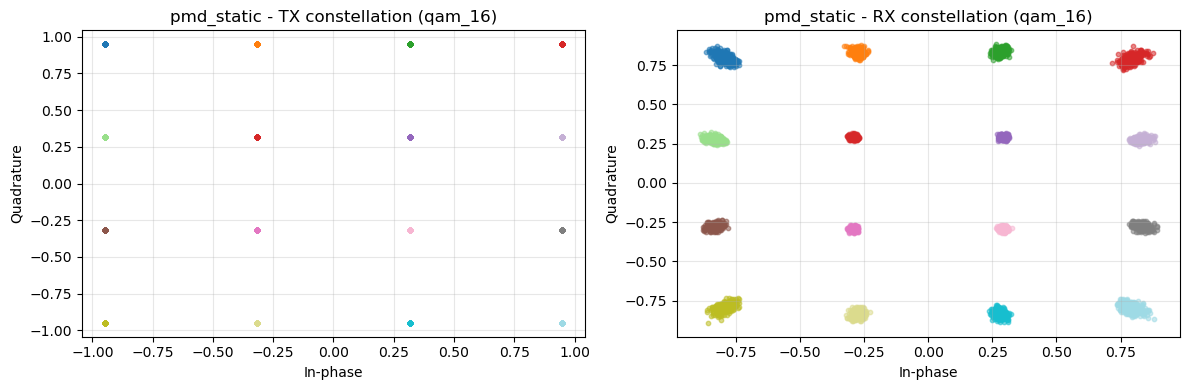

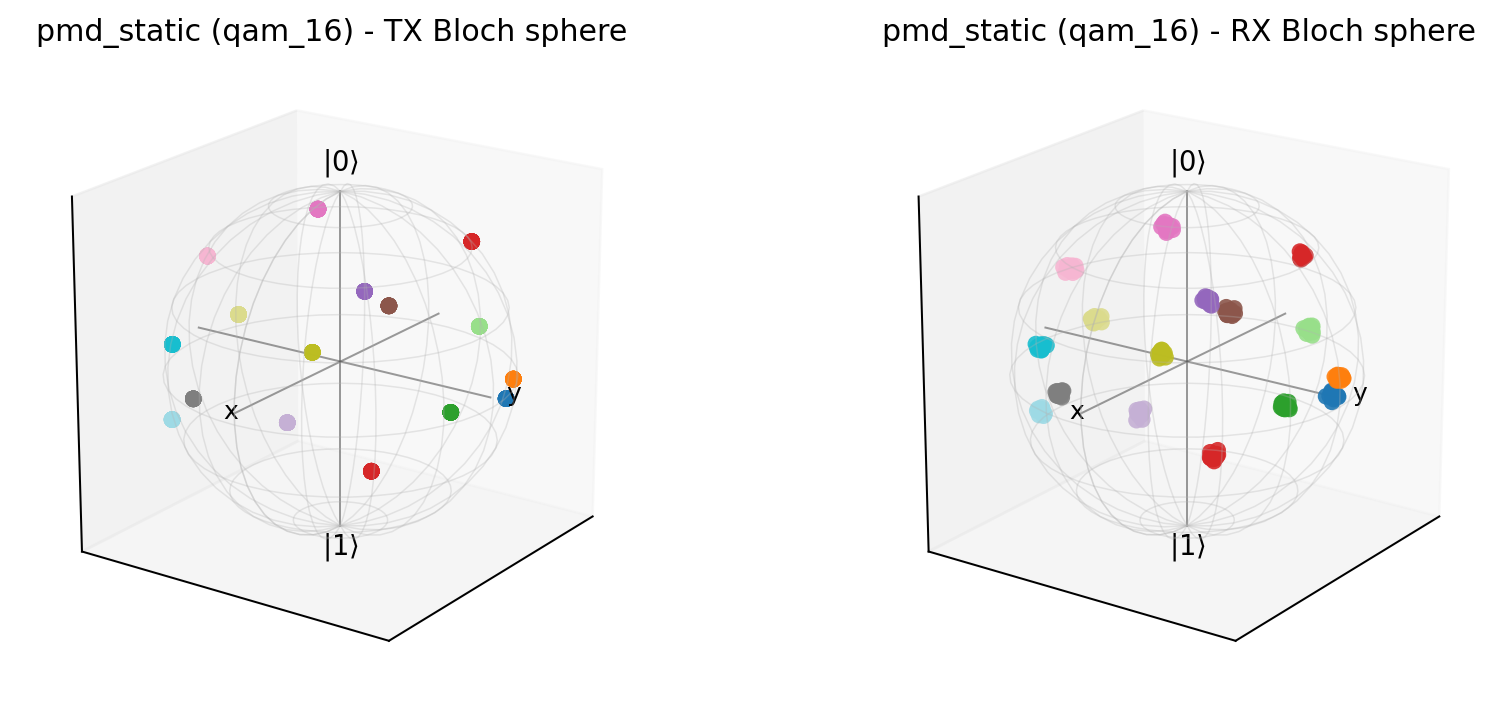

[depolarizing_p01    ] BER=0.0000e+00, SER=0.0000e+00
[depolarizing_p05    ] BER=0.0000e+00, SER=0.0000e+00
[dephasing_p05       ] BER=0.0000e+00, SER=0.0000e+00
[pmd_static          ] BER=0.0000e+00, SER=0.0000e+00
[turbulence_weak     ] BER=1.0319e-01, SER=3.1025e-01
[turbulence_strong   ] BER=1.3662e-01, SER=4.1200e-01
[bosonic_loss3db     ] BER=2.4725e-01, SER=7.5150e-01
[bosonic_loss6db     ] BER=2.4725e-01, SER=7.5150e-01
[erasure_p05         ] BER=1.0000e+00, SER=1.0000e+00
Saved summary to c:\Users\z642291\Downloads\workspace\quantum-comm-sim\notebooks\..\results\data\quantum_channel_baseline_summary_qam_16.txt


In [5]:
# Run sweep and visualize a few representative channels
channel_configs = get_channel_configs()

summary = []

for name, ch_fn in channel_configs.items():
    ch = ch_fn()
    ber, ser, tx_states, rx_states, tx_labels, _, _ = run_simulation(
        ch,
        num_symbols=NUM_SYMBOLS,
        seed=RNG_SEED,
        modulation=MODULATION,
        m_order=M_ORDER,
    )
    summary.append((name, ber, ser))

    # Constellation diagrams (TX / RX)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_constellation(axes[0], tx_states, f"{name} - TX constellation ({run_tag})",
                       labels=tx_labels)
    plot_constellation(axes[1], rx_states, f"{name} - RX constellation ({run_tag})",
                       labels=tx_labels)
    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, f"constellation_{name}_{run_tag}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

    # Bloch spheres with the same label colors as the IQ constellations
    bloch_fig = plot_bloch_spheres(
        tx_states,
        rx_states,
        f"{name} ({run_tag})",
        labels=tx_labels,
    )
    if bloch_fig is not None:
        bloch_path = os.path.join(FIG_DIR, f"bloch_{name}_{run_tag}.png")
        bloch_fig.savefig(bloch_path, dpi=220, bbox_inches="tight")

# Sort and store summary
summary = sorted(summary, key=lambda x: x[1])
for name, ber, ser in summary:
    print(f"[{name:20s}] BER={ber:.4e}, SER={ser:.4e}")

summary_path = os.path.join(DATA_DIR, f"quantum_channel_baseline_summary_{run_tag}.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("# name, BER, SER\n")
    for name, ber, ser in summary:
        f.write(f"{name}, {ber:.6e}, {ser:.6e}\n")

print(f"Saved summary to {summary_path}")